# 04 - Acoustic PINN-FWI
Joint PINN wavefield + VelocityNet inversion, with outputs in the legacy autoencoder plotting style.

In [1]:
from pathlib import Path
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / 'src').exists() else NOTEBOOK_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.io import load_yaml, seed_everything, get_device, resolve_path
from src.data import load_marmousi_vp
from src.forward import AcquisitionGeometry
from src.pinn.acoustic_pinn import AcousticPINN, AcousticPINNConfig
from src.pinn.velocity_net import VelocityNet, VelocityNetConfig
from src.inversion.trainer import AcousticPINNFWITrainer
from src.utils.viz import plot_losses, plot_true_vs_estimated, plot_well_log_comparison

CONFIG_FILE = 'marmousi_acoustic.yaml'
cfg = load_yaml(PROJECT_ROOT / 'configs' / CONFIG_FILE)
seed_everything(int(cfg['seed']))
device = get_device(cfg.get('device', 'auto'))
print('Device:', device)

Device: cuda


In [2]:
vp_true = load_marmousi_vp(resolve_path(PROJECT_ROOT, cfg['data']['vp_path']), subsample=int(cfg['model']['subsample']))
geom = AcquisitionGeometry.from_npz(PROJECT_ROOT / cfg['data']['geometry_path'])
observed = np.load(PROJECT_ROOT / cfg['data']['observed_path']).astype(np.float32)

obs_scale = float(np.max(np.abs(observed)))
if obs_scale > 0.0:
    observed = observed / obs_scale

global_receiver_rms = np.sqrt(np.mean(observed**2, axis=(0, 1)))
active_global = np.flatnonzero(global_receiver_rms > 0.02 * max(float(global_receiver_rms.max()), 1e-8))

print('Vp shape:', vp_true.shape, ' | Observed:', observed.shape)
print('Observed max abs after scaling:', float(np.max(np.abs(observed))))
print('Global active receivers:', int(active_global.size), '/', int(observed.shape[2]))
print('Shot count:', int(observed.shape[0]), ' | Receiver count:', int(observed.shape[2]), ' | nt:', int(observed.shape[1]))

Vp shape: (176, 681)  | Observed: (8, 1000, 169)
Observed max abs after scaling: 1.0
Global active receivers: 168 / 169
Shot count: 8  | Receiver count: 169  | nt: 1000


In [5]:
# Stability-focused overrides to match reference FWI behavior while keeping the PINN architecture.
cfg['pinn']['activation'] = 'sin'
cfg['pinn']['hidden_layers'] = int(cfg['pinn'].get('hidden_layers', 6))
cfg['pinn']['hidden_width'] = int(cfg['pinn'].get('hidden_width', 128))
cfg['pinn']['fourier_features'] = False

cfg['velocity_net']['output_activation'] = 'sigmoid'
cfg['velocity_net']['fourier_features'] = True
cfg['velocity_net']['n_fourier'] = int(cfg['velocity_net'].get('n_fourier', 128))
cfg['velocity_net']['fourier_scale'] = float(cfg['velocity_net'].get('fourier_scale', 8.0))

cfg['training']['alternating_updates'] = False
cfg['training']['warmup_pinn_only_epochs'] = 0
cfg['training']['shots_per_batch'] = int(cfg['acquisition']['n_shots'])
cfg['training']['data_batch_all_shots'] = True
cfg['training']['n_data_receivers'] = int(observed.shape[2])
cfg['training']['active_receiver_rms_ratio'] = 0.02
cfg['training']['data_normalization'] = 'rms'
cfg['training']['data_norm_floor_ratio'] = 0.10
cfg['training']['data_gain_match'] = False
cfg['training']['data_loss'] = 'smooth_l1'
cfg['training']['use_frequency_continuation'] = True
cfg['training']['freq_start_hz'] = 2.0
cfg['training']['freq_end_hz'] = float(cfg['acquisition']['f_peak'])
cfg['training']['freq_ramp_epochs'] = int(0.7 * cfg['training']['n_epochs'])
cfg['training']['grad_clip'] = 1.0
cfg['training']['lr_pinn'] = float(cfg['training'].get('lr_pinn', 1.0e-4))
cfg['training']['lr_vp'] = 3.0e-4
cfg['training']['use_well_prior'] = True
cfg['training']['well_position_fracs'] = [0.5]
cfg['training']['well_depth_frac'] = 0.75

cfg['weights']['w_pde_start'] = 0.2
cfg['weights']['w_pde'] = 4.0
cfg['weights']['w_data_start'] = 4.0
cfg['weights']['w_data'] = 30.0
cfg['weights']['w_ic_start'] = 20.0
cfg['weights']['w_ic_end'] = 2.0
cfg['weights']['adaptive_data_weight'] = True
cfg['weights']['w_reg'] = 1.0e-4
cfg['weights']['w_smooth'] = 5.0e-7
cfg['weights']['w_tv'] = 5.0e-6
cfg['weights']['w_charbonnier'] = 1.0e-5
cfg['weights']['w_bounds'] = 1.0e-4
cfg['weights']['w_well'] = 10.0

pinn_cfg = AcousticPINNConfig(
    in_dim=int(cfg['pinn'].get('in_dim', 4)),
    n_shots=int(cfg['pinn'].get('n_shots', cfg['acquisition']['n_shots'])),
    hidden_layers=int(cfg['pinn']['hidden_layers']),
    hidden_width=int(cfg['pinn']['hidden_width']),
    activation=str(cfg['pinn']['activation']),
    first_omega_0=float(cfg['pinn'].get('first_omega_0', 30.0)),
    hidden_omega_0=float(cfg['pinn'].get('hidden_omega_0', 30.0)),
    fourier_features=bool(cfg['pinn']['fourier_features']),
    n_fourier=int(cfg['pinn']['n_fourier']),
    fourier_scale=float(cfg['pinn']['fourier_scale']),
    allow_fourier_with_siren=bool(cfg['pinn'].get('allow_fourier_with_siren', False)),
    hard_constraint=str(cfg['pinn'].get('hard_constraint', 'exp')),
    hard_constraint_scale=float(cfg['pinn'].get('hard_constraint_scale', 1.0)),
    hard_constraint_power=int(cfg['pinn'].get('hard_constraint_power', 2)),
)
vel_cfg = VelocityNetConfig(
    hidden_layers=int(cfg['velocity_net']['hidden_layers']),
    hidden_width=int(cfg['velocity_net']['hidden_width']),
    activation=str(cfg['velocity_net']['activation']),
    fourier_features=bool(cfg['velocity_net'].get('fourier_features', False)),
    n_fourier=int(cfg['velocity_net'].get('n_fourier', 64)),
    fourier_scale=float(cfg['velocity_net'].get('fourier_scale', 6.0)),
    output_activation=str(cfg['velocity_net']['output_activation']),
    vp_min=float(cfg['model']['vp_min']),
    vp_max=float(cfg['model']['vp_max']),
    use_depth_trend_init=True,
    depth_trend_start=0.08,
    depth_trend_end=0.72,
)

pinn = AcousticPINN(pinn_cfg).to(device)
vel = VelocityNet(vel_cfg).to(device)
print('Configured data normalization:', cfg['training']['data_normalization'])
print('Configured data loss:', cfg['training']['data_loss'])
print('Data gain match:', cfg['training']['data_gain_match'])
print('Data batches use all shots:', cfg['training']['data_batch_all_shots'])
print('Active receiver RMS ratio:', cfg['training']['active_receiver_rms_ratio'])
print('Well prior enabled at center well:', cfg['training']['well_position_fracs'])
print('Velocity initialization: smooth depth trend')

Configured data normalization: rms
Configured data loss: smooth_l1
Data gain match: False
Data batches use all shots: True
Active receiver RMS ratio: 0.02
Well prior enabled at center well: [0.5]
Velocity initialization: smooth depth trend


Training epochs: 300


PINN-FWI:   0%|          | 0/300 [00:00<?, ?it/s]

[WEIGHTED] epoch=0 data=3.338e+00 pde=1.482e-02 bc=6.437e-06 ic=0.000e+00 reg=2.682e-08 well=9.785e-01


PINN-FWI:   4%|▎         | 11/300 [00:02<01:01,  4.74it/s, data=4.050e-01, fmax=2.3, mode=PV, pde=4.873e-02, total=1.689e+00]

[WEIGHTED] epoch=10 data=1.620e+00 pde=2.833e-02 bc=1.198e-06 ic=0.000e+00 reg=3.505e-08 well=8.503e-01


...

[WEIGHTED] epoch=280 data=4.021e+00 pde=2.556e-02 bc=9.510e-08 ic=0.000e+00 reg=1.068e-06 well=2.140e-02


PINN-FWI:  97%|█████████▋| 291/300 [01:02<00:01,  4.69it/s, data=1.470e-01, fmax=8.0, mode=PV, pde=4.876e-03, total=2.156e+00]

[WEIGHTED] epoch=290 data=4.237e+00 pde=1.950e-02 bc=9.994e-08 ic=0.000e+00 reg=1.047e-06 well=1.808e-02


PINN-FWI: 100%|██████████| 300/300 [01:04<00:00,  4.68it/s, data=1.373e-01, fmax=8.0, mode=PV, pde=5.992e-03, total=2.101e+00]


[Epoch 00300] L=2.1012e+00, L_data=1.3727e-01, L_pde=5.9920e-03, L_reg=1.0325e-02


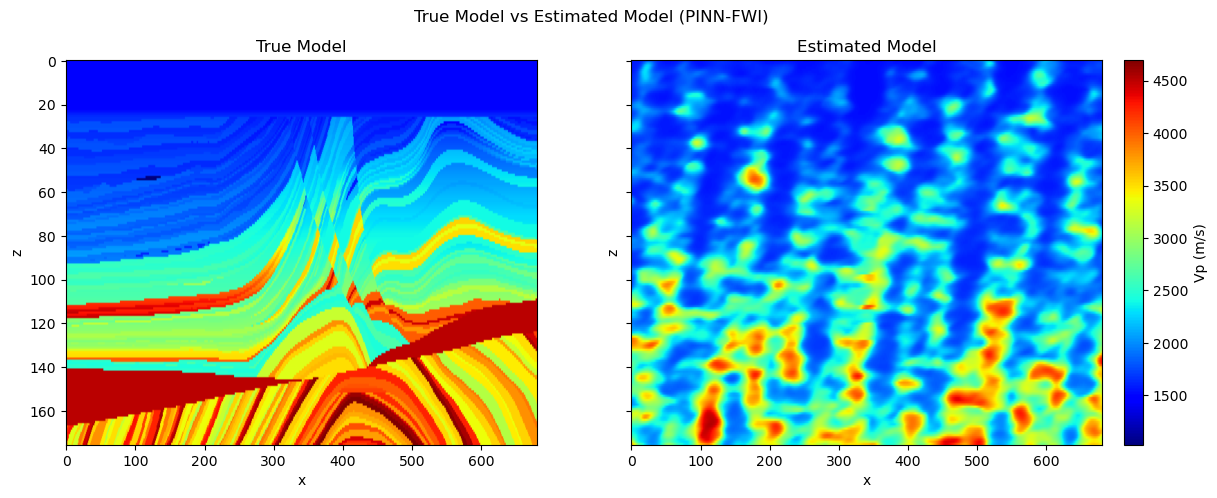

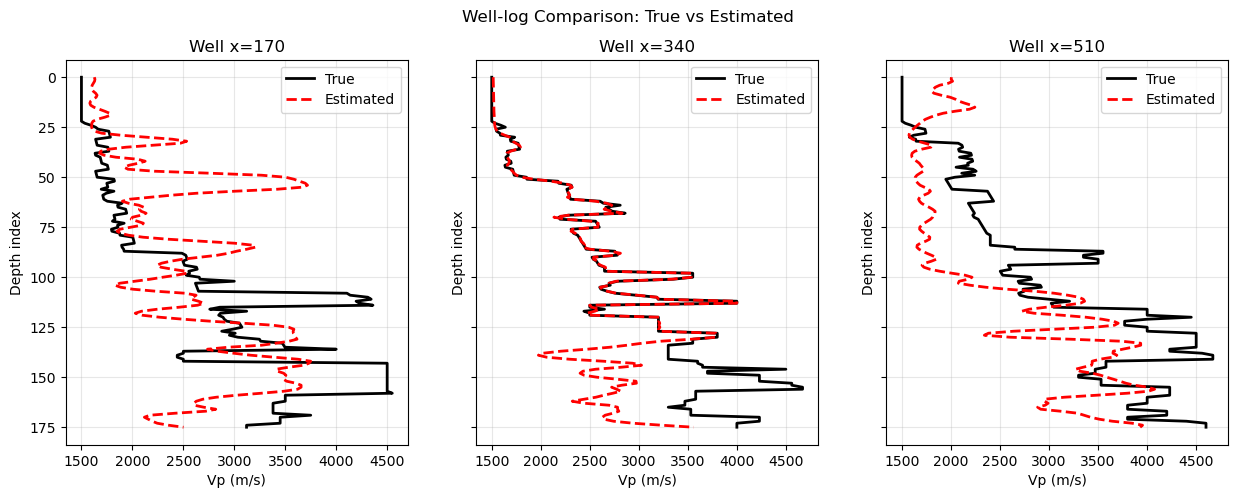

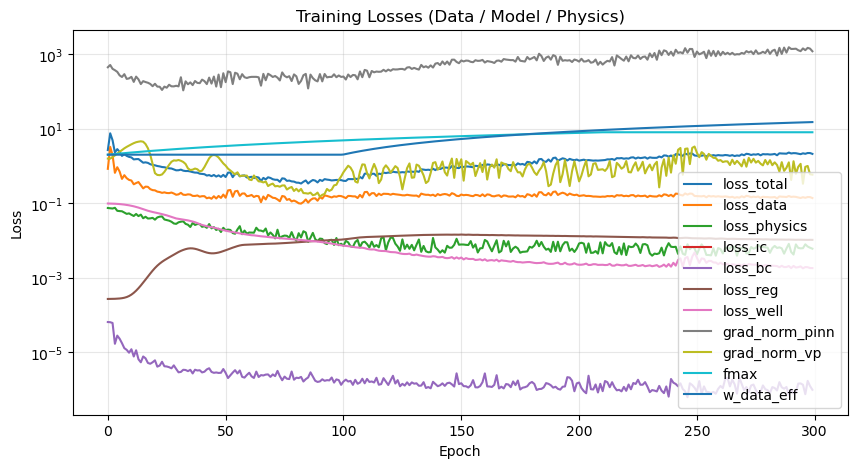

Shot 0 active receivers: 12 / 169
Shot 0 observed RMS: 0.024280648678541183
Shot 0 predicted RMS: 0.0006405386375263333
Final well loss: 0.0018091134261339903


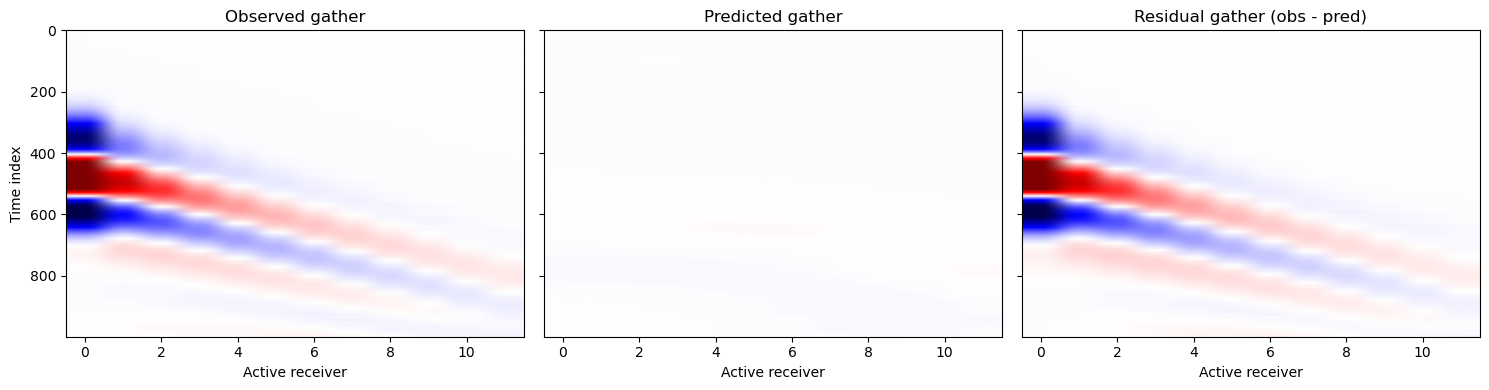

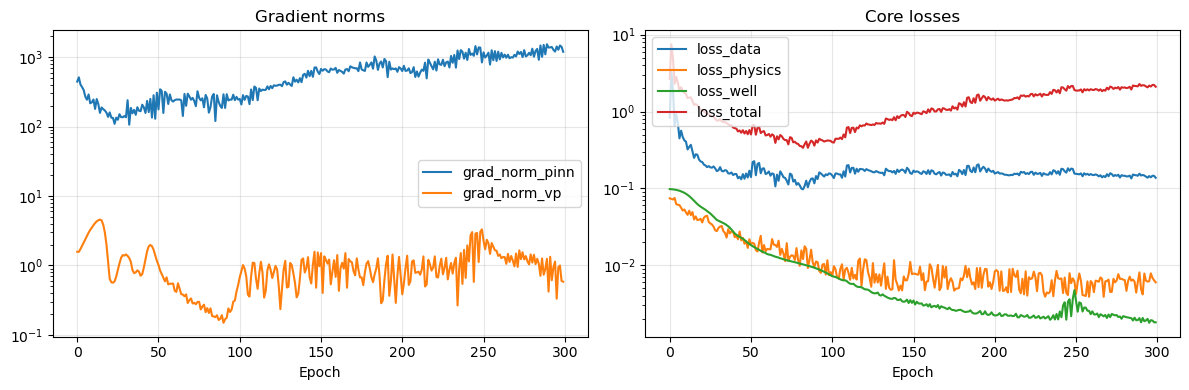

Saved: /root/FWI/pinn_acoustic_fwi/results/checkpoints/vp_est_final.npy


In [6]:
# Keep notebook runtime manageable while preserving the full schedule shape.
run_epochs = int(min(cfg['training']['n_epochs'], 300))
cfg['training']['n_epochs'] = run_epochs
print('Training epochs:', run_epochs)

trainer = AcousticPINNFWITrainer(
    pinn=pinn,
    velocity_net=vel,
    observed=observed,
    geometry=geom,
    vp_true=vp_true,
    config=cfg,
    project_root=PROJECT_ROOT,
    invert_vp=True,
)

history = trainer.train()
vp_est = trainer.estimate_velocity()

# Final outputs in old autoencoder project style
plot_true_vs_estimated(vp_true, vp_est, title='True Model vs Estimated Model (PINN-FWI)')
wells = [vp_true.shape[1] // 4, vp_true.shape[1] // 2, 3 * vp_true.shape[1] // 4]
plot_well_log_comparison(vp_true, vp_est, wells)
plot_losses(history)

# Observed vs predicted gather diagnostics
shot_id = 0
rec_x = geom.rec_x / max(vp_true.shape[1] - 1, 1)
rec_z = geom.rec_z / max(vp_true.shape[0] - 1, 1)
t_norm = geom.time / max(float(geom.time[-1]), 1e-8)

nrec, nt = len(rec_x), len(t_norm)
xx = np.broadcast_to(rec_x[:, None], (nrec, nt)).reshape(-1, 1)
zz = np.broadcast_to(rec_z[:, None], (nrec, nt)).reshape(-1, 1)
tt = np.broadcast_to(t_norm[None, :], (nrec, nt)).reshape(-1, 1)
sid = np.full((nrec * nt, 1), shot_id, dtype=np.int64)

with torch.no_grad():
    pred = trainer.pinn(
        torch.tensor(xx, dtype=torch.float32, device=device),
        torch.tensor(zz, dtype=torch.float32, device=device),
        torch.tensor(tt, dtype=torch.float32, device=device),
        torch.tensor(sid, dtype=torch.long, device=device),
    ).cpu().numpy().reshape(nrec, nt).T

obs = observed[shot_id, :, :nrec]
res = obs - pred
trace_rms = np.sqrt(np.mean(obs**2, axis=0))
thr = max(0.02 * float(trace_rms.max()), 1e-8)
active_idx = np.flatnonzero(trace_rms > thr)
if active_idx.size == 0:
    active_idx = np.arange(nrec)

obs_plot = obs[:, active_idx]
pred_plot = pred[:, active_idx]
res_plot = res[:, active_idx]
vabs = np.percentile(np.abs(obs_plot), 99) if obs_plot.size else 1.0

print('Shot 0 active receivers:', int(active_idx.size), '/', int(nrec))
print('Shot 0 observed RMS:', float(np.sqrt(np.mean(obs**2))))
print('Shot 0 predicted RMS:', float(np.sqrt(np.mean(pred**2))))
print('Final well loss:', float(history.get('loss_well', [np.nan])[-1]))

fig, ax = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
ax[0].imshow(obs_plot, aspect='auto', cmap='seismic', vmin=-vabs, vmax=vabs)
ax[0].set_title('Observed gather')
ax[0].set_xlabel('Active receiver')
ax[0].set_ylabel('Time index')

ax[1].imshow(pred_plot, aspect='auto', cmap='seismic', vmin=-vabs, vmax=vabs)
ax[1].set_title('Predicted gather')
ax[1].set_xlabel('Active receiver')

ax[2].imshow(res_plot, aspect='auto', cmap='seismic', vmin=-vabs, vmax=vabs)
ax[2].set_title('Residual gather (obs - pred)')
ax[2].set_xlabel('Active receiver')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.get('grad_norm_pinn', []), label='grad_norm_pinn')
ax[0].plot(history.get('grad_norm_vp', []), label='grad_norm_vp')
ax[0].set_yscale('log')
ax[0].set_title('Gradient norms')
ax[0].set_xlabel('Epoch')
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].plot(history.get('loss_data', []), label='loss_data')
ax[1].plot(history.get('loss_physics', []), label='loss_physics')
ax[1].plot(history.get('loss_well', []), label='loss_well')
ax[1].plot(history.get('loss_total', []), label='loss_total')
ax[1].set_yscale('log')
ax[1].set_title('Core losses')
ax[1].set_xlabel('Epoch')
ax[1].grid(True, alpha=0.3)
ax[1].legend()
plt.tight_layout()
plt.show()

out = PROJECT_ROOT / 'results' / 'checkpoints' / 'vp_est_final.npy'
out.parent.mkdir(parents=True, exist_ok=True)
np.save(out, vp_est.astype(np.float32))
print('Saved:', out)